# Mosaic Viewer — Doha, Qatar (City-Scale BigTIFFs)

*Track: demo · needs a mosaic run.*

**Case study:** Doha, Qatar (25.2886°N, 51.531°E) — municipality boundary via OSM Nominatim (query `Doha, Qatar`, OSM ID 27332, UTM 39N). Mosaic `run_mosaic.py` grids 4.12 km tiles on 4 km step, center-out, per-tile `run_location` subprocesses, `manifest.json` + `flock`, `gdalbuildvrt` + `gdalwarp` BigTIFFs (`<Place>_<date>_S2SR_*_1m.tif`, `COMPRESS=NONE`, `BIGTIFF=YES`).

**This notebook is Doha-only — Sousse LST is in `03`, Huntington oil in `02`, general demo in `01`.**

Visualizes `outputs/QA/<date>/mosaic-*/` BigTIFFs, downsampled preview, and `manifest.json` (tiles, retries, validation). Uses `folium` for boundary + `rasterio` windowed reads (no full mosaic load).


In [1]:
from pathlib import Path
import glob, json
ROOT = Path.cwd()
for _up in [ROOT, *ROOT.parents]:  # walk up: works from notebooks/<track>/ too
    if (_up / 'scripts' / 'run_location.py').exists():
        ROOT = _up
        break
cands = sorted(glob.glob(str(ROOT / "outputs" / "QA" / "*" / "mosaic-*")))  # Doha only
mosaic = Path(cands[-1]) if cands else None
print("latest mosaic", mosaic)
if mosaic:
    print(list(mosaic.glob("*.tif"))[:3])
    print((mosaic / ".work" / "manifest.json").exists(), (mosaic / "README.md").exists())
else:
    print("No mosaic yet — run: python scripts/run_mosaic.py --date 2026-08-14 --boundary-query 'Lyon, France' --osm-id 35238")


latest mosaic /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/QA/2026-08-14/mosaic-20260814-ff389a5a
[PosixPath('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/QA/2026-08-14/mosaic-20260814-ff389a5a/Doha_20260814_S2SR_MS_1m.tif')]
False True


## 1. Manifest — tiles, retries, validation

In [2]:
import json
from pathlib import Path
if mosaic and (mosaic / ".work" / "manifest.json").exists():
    m=json.loads((mosaic / ".work" / "manifest.json").read_text())
    print(f"state {m.get('state')}  tiles {len(m.get('tiles',[]))}  products {list(m.get('products',{}).keys())}")
    import pandas as pd
    df=pd.DataFrame([{"id":t["id"], "status":t["status"], "attempts":t["attempts"], "lon":t["longitude"], "lat":t["latitude"]} for t in m["tiles"][:8]])
    display(df)
elif mosaic:
    print(open(mosaic/"README.md").read().splitlines()[:20])


['# S2SR Mosaic Metadata', '', 'Generated: 2026-09-23T00:16:39+00:00 UTC', '', '## Run', '', '- inference_id: mosaic-20260814-ff389a5a', '- country_code: QA', '- request_date: 2026-08-14', '- state: completed', '- workspace: /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/QA/2026-08-14/mosaic-20260814-ff389a5a/.work', '- started_at: 2026-09-22T23:45:00+00:00', '- completed_at: 2026-09-23T00:16:31+00:00', '- tiles_completed: 4', '- tiles_total: 4', '- tiles_failed: none', '', '## Boundary', '', '- source: OpenStreetMap/Nominatim']


## 2. Preview — downsampled TCI + boundary
The mosaic preview is `*_preview.tif` (2048 px wide, from TCI). Boundary is `boundary.geojson` in `.work`.


In [3]:
import rasterio, matplotlib.pyplot as plt, json
from pathlib import Path
if mosaic:
    preview = sorted(mosaic.glob("*preview.tif"))
    preview = preview[0] if preview else None
    if preview and preview.exists():
        with rasterio.open(preview) as s:
            w=512; rgb=s.read(window=rasterio.windows.Window(s.width//2-256, s.height//2-256, w, w)).transpose(1,2,0)
            plt.figure(figsize=(6,6)); plt.imshow(rgb); plt.title(f"{preview.name} preview"); plt.axis("off"); plt.show()
        print(preview, s.width, s.height)
    else:
        print("No preview yet")
    # Folium boundary if available
    bpath = mosaic / ".work" / "boundary.geojson" if mosaic else None
    if bpath and bpath.exists():
        import folium
        gj=json.loads(bpath.read_text())
        # crude center from first feature
        coords=gj["features"][0]["geometry"]["coordinates"][0][0] if gj["features"][0]["geometry"]["type"]=="Polygon" else gj["features"][0]["geometry"]["coordinates"][0][0][0]
        lon, lat = coords[0], coords[1]
        m=folium.Map(location=[lat, lon], zoom_start=11)
        folium.GeoJson(gj, name="boundary").add_to(m); m
    else:
        print("No boundary.geojson (mosaic not started)")


No preview yet
No boundary.geojson (mosaic not started)


## 3. Windowed read — BigTIFF without loading it all
Mosaics are ~tens of GB at 1 m. Use `rasterio.windows.Window` to read a 1024×1024 chip.

MS 25271x26869 10 bands uint16 EPSG:32639
chip (10, 1024, 1024) mean DN 1.0


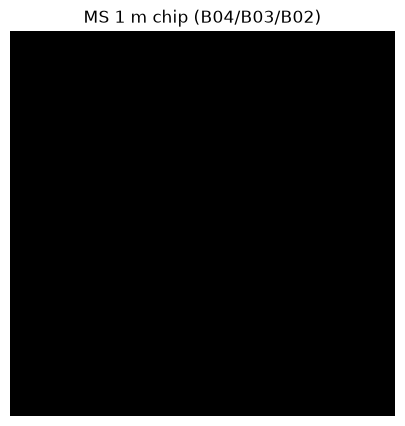

In [4]:
import rasterio
from pathlib import Path
if mosaic:
    ms = sorted(mosaic.glob("*S2SR_MS_1m.tif"))
    ms = ms[0] if ms else None
    if ms and ms.exists():
        with rasterio.open(ms) as s:
            print(f"MS {s.width}x{s.height} {s.count} bands {s.dtypes[0]} {s.crs}")
            w=1024; win=rasterio.windows.Window(s.width//2-512, s.height//2-512, w, w)
            chip=s.read(window=win).astype(float)
            print(f"chip {chip.shape} mean DN {chip.mean():.1f}")
            import matplotlib.pyplot as plt, numpy as np
            rgb=np.dstack([chip[2], chip[1], chip[0]])  # B04,B03,B02
            # quick stretch
            def stretch(b):
                lo,hi=np.percentile(b,(2,98))
                return np.clip((b-lo)*(255/(hi-lo+1e-6)),0,255).astype(np.uint8)
            rgb=np.dstack([stretch(chip[2]), stretch(chip[1]), stretch(chip[0])])
            plt.figure(figsize=(5,5)); plt.imshow(rgb); plt.title("MS 1 m chip (B04/B03/B02)"); plt.axis("off"); plt.show()
    else:
        print("No MS BigTIFF yet")


## 4. Interactive product inspector — any mosaic BigTIFF, windowed (no full load)

Live in JupyterLab; picks any mosaic product under outputs/.


In [ ]:
# Windowed inspector: downsampled view + percentile stretch (BigTIFF-safe, never loads full raster)
import glob as _g, numpy as _np, matplotlib.pyplot as _plt, rasterio as _r
cands = sorted(_g.glob(str(ROOT / 'outputs' / '*' / '*' / '*' / '*_S2SR_*.tif')))
print(f'{len(cands)} mosaic products found')
def _show_mosaic(path, lo=2, hi=98, max_px=1024):
    import math as _m
    with _r.open(path) as s:
        f = max(1, _m.ceil(max(s.width, s.height) / max_px))
        a = s.read(out_shape=(s.count, s.height // f, s.width // f))
    rgb = _np.moveaxis(a[:3], 0, -1).astype(float) if a.shape[0] >= 3 else a[0].astype(float)
    v = rgb[_np.isfinite(rgb)]; l, u = _np.percentile(v, [lo, hi])
    fig, ax = _plt.subplots(figsize=(8, 8))
    ax.imshow(_np.clip((rgb - l) / max(u - l, 1e-9), 0, 1), cmap=None if rgb.ndim == 3 else 'gray')
    ax.set_title(f'{Path(path).name}  1:{f} p{lo}-p{hi}'); ax.axis('off')
    _plt.show()
try:
    import ipywidgets as _w
    from IPython.display import display as _d
    if not cands:
        print('No mosaic products on disk.')
        print('Generate one: python scripts/run_mosaic.py --boundary-query "Doha, Qatar" --date YYYY-MM-DD')
    else:
        _dd = _w.Dropdown(options=cands, value=cands[-1], description='Product:')
        _ss = _w.IntRangeSlider(value=[2, 98], min=0, max=100, description='Stretch:')
        _o = _w.Output()
        def _u(*a):
            _o.clear_output(wait=True)
            with _o: _show_mosaic(_dd.value, *_ss.value)
        _dd.observe(_u, 'value'); _ss.observe(_u, 'value')
        _d(_dd, _ss, _o); _u()
except Exception as _e:
    print('inspector needs Jupyter widgets + a mosaic on disk:', _e)
